In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
import os
import glob
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO
from collections import Counter

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from hybrid_phoneme_models import HybridPhonemeModels
from pipeline import UnifiedPhonemePipeline
from markov_phoneme_model import MarkovPhonemeModel
from markov_children import  GMMHMMModel, HSMMModel

In [3]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'
path_output = './features'
path_results = './results'

# Create directories if they don't exist
os.makedirs(path_output, exist_ok=True)
os.makedirs(path_results, exist_ok=True)

In [4]:
# pipeline = UnifiedPhonemePipeline(
#     path_bids=path_bids,
#     path_output=path_output,
#     path_results=path_results,
#     feature_extraction_method='high_gamma',
#     pca_components=20,  # Using 20 components instead of default 50
#     debug_mode=True
# )

# # Or find the optimal PCA components first
# best_components, results = pipeline.optimize_pca_components(
#     component_values=[10, 20, 30, 40, 50, 60, 70]
# )

In [5]:
# Pipeline creation with PCA components management
use_augmentation = True
feature_extraction_method = 'high_gamma'#'spectral'#'high_gamma' #'multi_band' #'high_gamma'  # 'multi_band'
optimal_pca_components = 50  # Use your optimal value determined earlier

pipeline_loaded = False

def try_load_pipeline(path_results, feature_extraction_method, optimal_pca_components):
    """Try to load an existing pipeline with error handling."""
    
    # Find all matching pipeline files
    pattern = f"pipeline_{feature_extraction_method}_*.pkl"
    matching_files = glob.glob(os.path.join(path_results, pattern))
    
    if not matching_files:
        print(f"No {feature_extraction_method} pipeline files found")
        return None
    
    # Sort by modification time (newest first)
    matching_files.sort(key=lambda f: os.path.getmtime(f), reverse=True)
    
    # Try loading files until we find one that works
    for filepath in matching_files:
        try:
            filename = os.path.basename(filepath)
            print(f"Trying to load: {filename}")
            
            # Check file size first
            file_size = os.path.getsize(filepath)
            if file_size < 100:  # If file is suspiciously small
                print(f"  File appears corrupted (size: {file_size} bytes). Skipping...")
                continue
            
            # Try to load the pipeline
            pipeline = UnifiedPhonemePipeline(path_results, path_results, path_results
                                             )
            pipeline.load(filepath)
            
            print(f"Successfully loaded: {filename}")
            return pipeline
            
        except (EOFError, pickle.UnpicklingError) as e:
            print(f"  File is corrupted: {e}. Trying next file...")
            continue
        except Exception as e:
            print(f"  Error loading file: {e}. Trying next file...")
            continue
    
    print("No valid pipeline files could be loaded")
    return None

# # Try to load existing pipeline
pipeline = try_load_pipeline(path_results, feature_extraction_method, optimal_pca_components)

No high_gamma pipeline files found


In [6]:
if pipeline is not None:
    print(f"Loaded existing {feature_extraction_method} pipeline")
    
    # Check and update PCA components if needed
    current_pca = getattr(pipeline, 'pca_components', None)
    if current_pca != optimal_pca_components:
        print(f"Updating PCA components from {current_pca} to {optimal_pca_components}")
        pipeline.set_pca_components(optimal_pca_components)
        
        # Re-run data steps with new PCA components
        print("Re-processing data with updated PCA components...")
        
        # Make sure we have the necessary components initialized
        if not hasattr(pipeline, 'custom_decoder'):
            pipeline.step1_initialize_decoder()
        if not hasattr(pipeline, 'participant_strata'):
            pipeline.step2_stratify_participants()
        if not hasattr(pipeline, 'split_result'):
            pipeline.step3_create_split()
            
        pipeline.step4_initialize_detector()    
        pipeline.step5_accumulate_data()
        pipeline.step6_resolve_unknowns()
        pipeline.step7_filter_unknowns()
        
        # Save the updated pipeline
        pipeline.save()
        print(f"Updated and saved {feature_extraction_method} pipeline with {optimal_pca_components} PCA components")
else:
    # No existing pipeline found or all were corrupted, create new one
    print(f"Creating new {feature_extraction_method} pipeline...")
    
    pipeline = UnifiedPhonemePipeline(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        feature_extraction_method=feature_extraction_method,
        unknown_keep_ratio=0.1,
        channel_correlation_threshold=0.3,  # ADD THIS
        prioritize_regions=True,  # ADD THIS
        channel_selection='best_correlation', #'motor'/'best_correlation'
        pca_components=optimal_pca_components,  # Set optimal PCA components
        debug_mode=False
    )
    
    # Run all steps
    print("Running pipeline steps...")
    pipeline.step1_initialize_decoder()
    pipeline.step2_stratify_participants()    
    pipeline.step3_create_split()
    pipeline.step4_initialize_detector()    
    pipeline.step5_accumulate_data()
    pipeline.step6_resolve_unknowns()
    pipeline.step7_filter_unknowns()
    
    # Save the pipeline
    pipeline.save()
    print(f"Created and saved new {feature_extraction_method} pipeline with {optimal_pca_components} PCA components")

# The pipeline is now ready to use with optimal PCA components
print(f"Pipeline ready with {feature_extraction_method} features and {optimal_pca_components} PCA components")

Creating new high_gamma pipeline...
PhoneticDictionary: Initialized with DEBUG_MODE=False
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=50, groups=True
Running pipeline steps...
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
Step 1: Decoder initialized with PCA components=50
CustomBrainAudioDecoder: 
Participant stratification results:
CustomBrainAudioDecoder:   Participants with most relevant channels: 3
CustomBrainAudioDecoder:   Participants with relevant channels: 4
CustomBrainAudioDecoder:   Participants with least relevant channels: 3
CustomBrainAudioDecoder: 
Top participants by channel quality:
UnifiedPhonemePipeline: Filtered to 0 participants with good coverage
CustomBrainAudioDecoder: Segmenting data for sub-01...
CustomBrainAudioDecoder: 
  Top 5 most frequent words:
CustomBrainAudioDecoder:     1. 'helft': 1 instances
CustomBrainAudioDecoder:     2. 'hierop': 1 instances
CustomBrainAudioDecoder:     3. 'stiekem': 1 insta

In [7]:
from phonetic_dictionary import PhoneticDictionary
phonetic_dict = PhoneticDictionary()

PhoneticDictionary: Initialized with DEBUG_MODE=False


In [8]:
# Get FILTERED data (this is what you feed to the Markov model):
train_data = pipeline.get_training_data(filtered=True)  # or pipeline.train_filtered

# Extract all components:
filtered_features = train_data['features']
filtered_labels = train_data['phoneme_labels']
filtered_words = train_data['phoneme_words']
filtered_participants = train_data['phoneme_participant_ids']

test_features = pipeline.test['features']
test_labels = pipeline.test['phoneme_labels']

In [9]:
# Initiate:
markov_model = MarkovPhonemeModel(
    phonetic_dict=phonetic_dict,
    order=2,
    output_dir=os.path.join(path_results, 'markov_model'),
    debug_mode=True
)

gmm_model = GMMHMMModel(
    phonetic_dict=phonetic_dict,
    order=2,
    n_mix=5,
    output_dir=os.path.join(path_results, 'gmm_hmm'),
    debug_mode=True
)

hsmm_model = HSMMModel(
        phonetic_dict=phonetic_dict,
        order=2,
        max_duration=50,
        output_dir=os.path.join(path_results, 'hsmm'),
        debug_mode=False
    )

MarkovPhonemeModel: Initialized with DEBUG_MODE=True
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=2
MarkovPhonemeModel: Initialized with DEBUG_MODE=True
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=2
MarkovPhonemeModel: Initialized GMM-HMM with 5 mixtures per state
MarkovPhonemeModel: Initialized with DEBUG_MODE=False
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=2
MarkovPhonemeModel: Initialized HSMM with max duration 50


In [10]:
results = {}
train_parameters = {
    'features': filtered_features,
    'phoneme_labels': filtered_labels,
    'words': filtered_words,
    'participant_ids': filtered_participants
}

test_parameters = {
    'features': test_features,
    'true_labels': test_labels,  # Note: evaluate() uses 'true_labels' not 'phoneme_labels'
    'use_viterbi': True
}

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 25 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 155 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: Model saved to ./results\markov_model\markov_model.pkl
MarkovPhonemeModel [DEBUG]: Fir

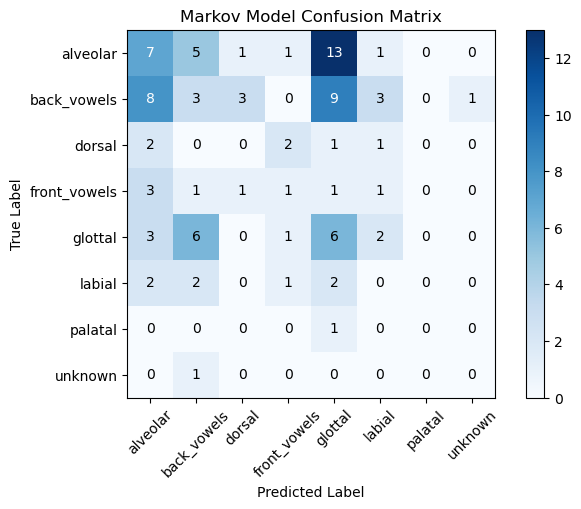

UnifiedPhonemePipeline: Metrics plot saved to ./results\markov_model\model_viz_20250830_191355\markov_model_metrics.png


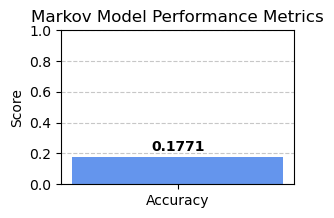

{'confusion_matrix': './results\\markov_model\\model_viz_20250830_191355\\markov_model_confusion_matrix.png',
 'metrics': './results\\markov_model\\model_viz_20250830_191355\\markov_model_metrics.png'}

In [11]:
# Train the Markov model
markov_training_results = markov_model.train(**train_parameters)
markov_eval = markov_model.evaluate(**test_parameters)

pipeline.visualize_model_results(
    model=markov_model, 
    eval_results=markov_eval,
    title_prefix="Markov Model", 
    figsize=(7, 5)
)

In [12]:
gmm_model.train(**train_parameters)
gmm_eval = gmm_model.evaluate(**test_parameters)

pipeline.visualize_model_results(
    model=gmm_model, 
    eval_results=gmm_eval,
    title_prefix="GMM Model", 
    figsize=(7, 5)
)

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 25 contexts
MarkovPhonemeModel: Building GMM acoustic model...
MarkovPhonemeModel: Trained GMM for 'alveolar' with 5 components on 52 samples
MarkovPhonemeModel: Trained GMM for 'back_vowels' with 5 components on 40 samples
MarkovPhonemeModel: Trained GMM for 'dorsal' with 5 components on 10 samples
MarkovPhonemeModel: Trained GMM for 'labial' with 5 components on 24 samples
MarkovPhonemeModel: Trained GMM for 'palatal' with 5 components on 11 samples
MarkovPhonemeModel: Trained GMM for 'fr

ValueError: Found array with 1 sample(s) (shape=(1, 50)) while a minimum of 2 is required by GaussianMixture.

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 25 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 155 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: HSMM model saved to ./results\hsmm\hsmm_model.pkl
MarkovPhonemeModel: Adding duration 

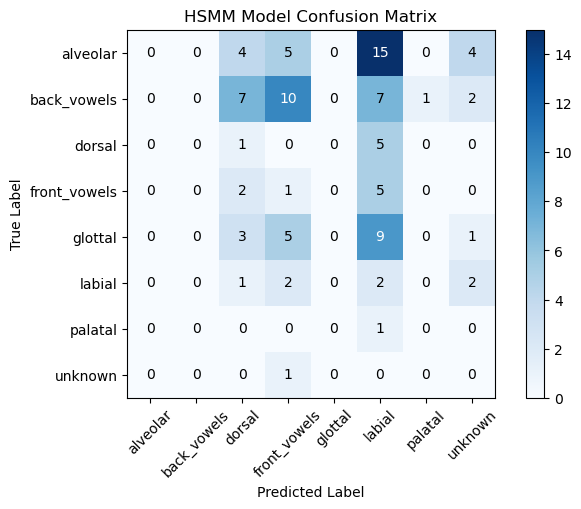

UnifiedPhonemePipeline: Metrics plot saved to ./results\hsmm\model_viz_20250830_191355\hsmm_model_metrics.png


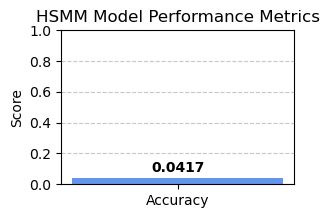

{'confusion_matrix': './results\\hsmm\\model_viz_20250830_191355\\hsmm_model_confusion_matrix.png',
 'metrics': './results\\hsmm\\model_viz_20250830_191355\\hsmm_model_metrics.png'}

In [13]:
hsmm_model.train(**train_parameters)    
hsmm_eval = hsmm_model.evaluate(**test_parameters)

pipeline.visualize_model_results(
    model=hsmm_model, 
    eval_results=hsmm_eval,
    title_prefix="HSMM Model", 
    figsize=(7, 5)
)

In [14]:
# Optional: Clean up corrupted files
def cleanup_corrupted_files(path_results, feature_extraction_method):
    """Remove corrupted pickle files."""
    
    pattern = f"pipeline_{feature_extraction_method}_*.pkl"
    files = glob.glob(os.path.join(path_results, pattern))
    
    corrupted = []
    for filepath in files:
        file_size = os.path.getsize(filepath)
        if file_size < 100:  # Suspiciously small
            corrupted.append(filepath)
            
    if corrupted:
        print(f"\nFound {len(corrupted)} corrupted files:")
        for f in corrupted:
            print(f"  - {os.path.basename(f)} ({os.path.getsize(f)} bytes)")
        
        response = input("Remove corrupted files? (y/n): ")
        if response.lower() == 'y':
            for f in corrupted:
                os.remove(f)
                print(f"Removed: {os.path.basename(f)}")
    
    return len(corrupted)

# Uncomment to clean up corrupted files
cleanup_corrupted_files(path_results, feature_extraction_method)

0

In [15]:
# Get FILTERED data (this is what you feed to the Markov model):
balance_strategy = 'weighted' #'undersample'#

train_data = pipeline.get_training_data(filtered=True)  # or pipeline.train_filtered

balanced_train_data = pipeline.balance_training_data(
                    train_data, 
                    balance_strategy = balance_strategy # 'weighted' #'undersample'#
                )

# Extract all components:
balanced_features = balanced_train_data['features']
balanced_labels = balanced_train_data['phoneme_labels']
balanced_words = balanced_train_data['phoneme_words']
balanced_participants = balanced_train_data['phoneme_participant_ids']

# test_features = pipeline.test['features']
# test_labels = pipeline.test['phoneme_labels']


balanced_train_parameters = {
    'features': filtered_features,
    'phoneme_labels': filtered_labels,
    'words': filtered_words,
    'participant_ids': filtered_participants
}

balanced_test_parameters = {
    'features': test_features,
    'true_labels': test_labels,  # Note: evaluate() uses 'true_labels' not 'phoneme_labels'
    'use_viterbi': True
}

UnifiedPhonemePipeline: Working with phoneme labels, mapping to groups for balancing
UnifiedPhonemePipeline: Original distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
UnifiedPhonemePipeline: Balanced distribution: {'v': 11, 'j': 3, 'k': 31, 'r': 44, 'f': 6, 'ɪ': 4, 'ə': 8, 'h': 57, 'ɑ': 4, 't': 8, 'ɑu': 1, 'n': 6, 'm': 12, 'd': 11, 'ʋ': 2, 's': 6, 'aː': 4, 'eː': 4, 'l': 4, 'ɛi': 6, 'z': 3, 'ɛ': 2, 'ɔ': 1, 'ɣ': 4, 'b': 6, 'oː': 1, 'i': 2, 'x': 12, 'tʋ': 9, 'ʏ': 1, 'p': 1}


MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 25 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 155 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: Model saved to ./results\markov_model\markov_model.pkl
MarkovPhonemeModel [DEBUG]: Fir

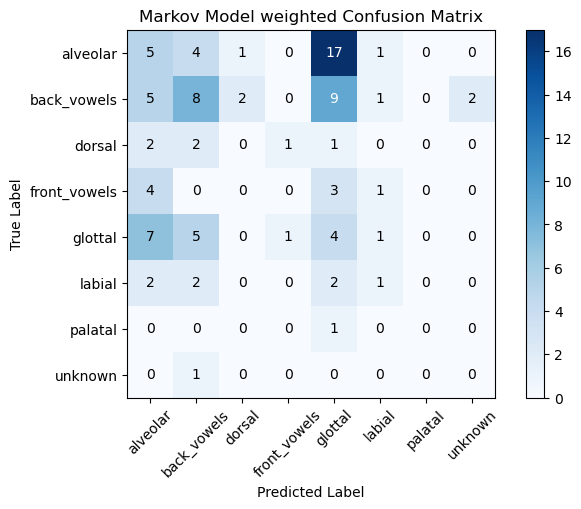

UnifiedPhonemePipeline: Metrics plot saved to ./results\markov_model\model_viz_20250830_191355\markov_model_weighted_metrics.png


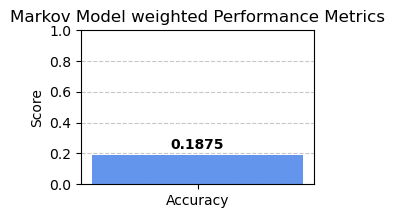

{'confusion_matrix': './results\\markov_model\\model_viz_20250830_191355\\markov_model_weighted_confusion_matrix.png',
 'metrics': './results\\markov_model\\model_viz_20250830_191355\\markov_model_weighted_metrics.png'}

In [16]:
# Train the Markov model
markov_training_results = markov_model.train(**balanced_train_parameters)
markov_eval = markov_model.evaluate(**balanced_test_parameters)

pipeline.visualize_model_results(
    model=markov_model, 
    eval_results=markov_eval,
    title_prefix=f"Markov Model {balance_strategy}", 
    figsize=(7, 5)
)

In [17]:
gmm_model.train(**balanced_train_parameters)
gmm_eval = gmm_model.evaluate(**balanced_test_parameters)

pipeline.visualize_model_results(
    model=gmm_model, 
    eval_results=gmm_eval,
    title_prefix= f"GMM Model {balance_strategy}", 
    figsize=(7, 5)
)

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 25 contexts
MarkovPhonemeModel: Building GMM acoustic model...
MarkovPhonemeModel: Trained GMM for 'alveolar' with 5 components on 52 samples
MarkovPhonemeModel: Trained GMM for 'back_vowels' with 5 components on 40 samples
MarkovPhonemeModel: Trained GMM for 'dorsal' with 5 components on 10 samples
MarkovPhonemeModel: Trained GMM for 'labial' with 5 components on 24 samples
MarkovPhonemeModel: Trained GMM for 'palatal' with 5 components on 11 samples
MarkovPhonemeModel: Trained GMM for 'fr

ValueError: Found array with 1 sample(s) (shape=(1, 50)) while a minimum of 2 is required by GaussianMixture.

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 52, 'back_vowels': 40, 'dorsal': 10, 'labial': 24, 'palatal': 11, 'front_vowels': 15, 'glottal': 2, 'unknown': 1}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 25 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 155 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: HSMM model saved to ./results\hsmm\hsmm_model.pkl
MarkovPhonemeModel: Adding duration 

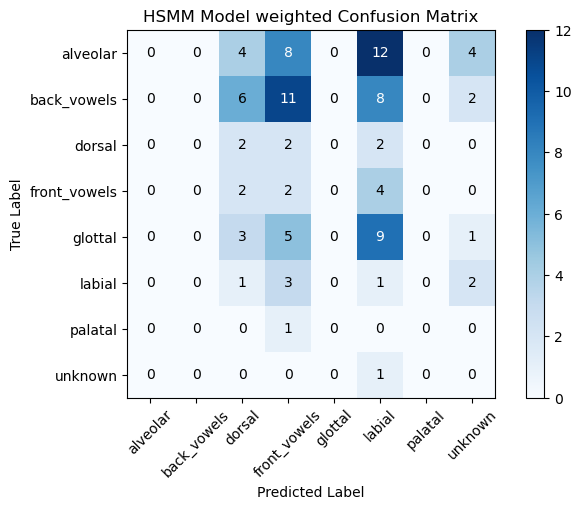

UnifiedPhonemePipeline: Metrics plot saved to ./results\hsmm\model_viz_20250830_191355\hsmm_model_weighted_metrics.png


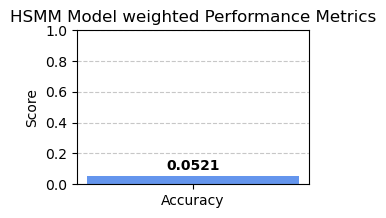

{'confusion_matrix': './results\\hsmm\\model_viz_20250830_191355\\hsmm_model_weighted_confusion_matrix.png',
 'metrics': './results\\hsmm\\model_viz_20250830_191355\\hsmm_model_weighted_metrics.png'}

In [18]:
hsmm_model.train(**balanced_train_parameters)    
hsmm_eval = hsmm_model.evaluate(**balanced_test_parameters)

pipeline.visualize_model_results(
    model=hsmm_model, 
    eval_results=hsmm_eval,
    title_prefix= f"HSMM Model {balance_strategy}", 
    figsize=(7, 5)
)

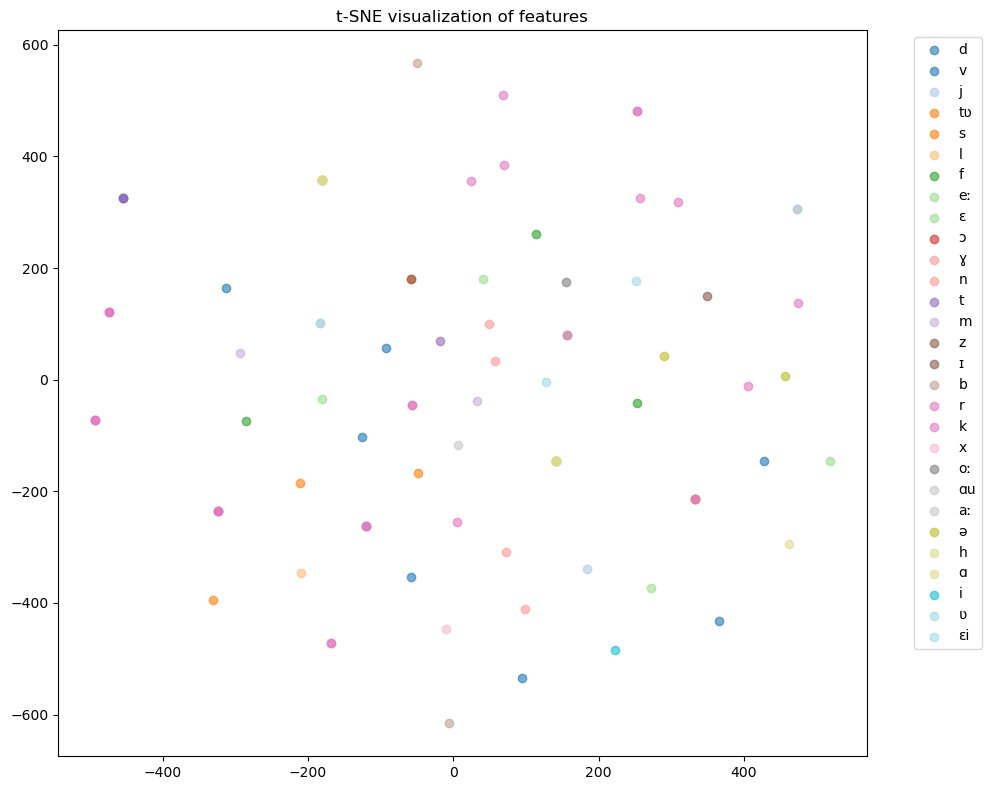

In [19]:
def visualize_feature_quality(train_data, n_samples=100):
    """Visualize feature quality using t-SNE."""
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Get a subset of features
    features = train_data['features'][:n_samples]
    labels = train_data['phoneme_labels'][:n_samples]
    
    # Flatten features if needed
    X = []
    for f in features:
        X.append(f.flatten()[:1000])  # Limit to 1000 features
    X = np.array(X)
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X)
    
    # Plot
    plt.figure(figsize=(10, 8))
    unique_labels = list(set(labels))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = [l == label for l in labels]
        plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], 
                   c=[colors[i]], label=label, alpha=0.6)
    
    plt.title('t-SNE visualization of features')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run this visualization
visualize_feature_quality(balanced_train_data)